# 01 — Exploration and Base CTMC Model

SYS 3060 final project — **NYC Citi Bike station capacity reallocation.**

This notebook does three things:

1. **Surface candidate clusters** of 3–4 neighbouring stations with high directional imbalance during the weekday morning rush.
2. **Validate the exponential inter-arrival assumption** that the birth–death CTMC requires, using Q-Q plots, chi-squared, and KS tests on each station × event-type stream.
3. **Compute the base model** — per-station stationary distributions $\pi_k(n)$, stockout/dockblock probabilities, failure rate $F_n$, and the total baseline $F_{\text{base}} = \sum_n F_n$.

All modelling math lives in `src/ctmc.py`; IO and rate estimation in `src/data.py`; geographic helpers in `src/geo.py`. The next notebook (`02_capacity_reallocation.ipynb`) imports from the same package and starts from the CSV this notebook writes.

Data window: **December 2021, weekday mornings 07:00–10:00 local time.**

# Citation
Developed alongside Claude Code (Opus 4.6)


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

# Make the project root importable regardless of CWD.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

from src import ctmc, data as dataio, geo

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# --- global knobs -----------------------------------------------------------
YEAR_MONTH       = "202112"   # December 2021
START_HOUR       = 7          # inclusive
END_HOUR         = 10         # exclusive -> 3-hour window
MIN_EVENTS       = 100        # per-station minimum; drops noisy low-volume stations

# Imbalance thresholds for station classification (rho = mu / lam).
SOURCE_RHO_MAX   = 0.7        # rho below this -> 'source' (runs dry)
SINK_RHO_MIN     = 1.5        # rho above this -> 'sink'   (overfills)

# Cluster-assembly knobs.
N_SINK_SEEDS     = 20         # seed count: top sinks by volume * |log rho|
K_ORIGINS        = 3          # top-K origin stations feeding into each seed sink
MAX_CLUSTER_SIZE = 5
MIN_CLUSTER_EVENTS = 2000     # gate: total events across cluster members
NEARBY_SINK_KM   = 1.0        # radius for optional extra-sink inclusion

TOP_CLUSTERS     = 10         # rows to show in the ranked candidate table

print("root:", ROOT)
print("raw :", RAW_DIR)


root: /Users/parisphan/Github/sys-3060-final-project
raw : /Users/parisphan/Github/sys-3060-final-project/data/raw


## Part 1 — Surface candidate clusters (routing-aware)

The previous revision picked clusters by geographic nearest-neighbours of the most-imbalanced seed. That surfaced four sinks clustered at the Brooklyn Navy Yard with no source stations — a cluster that can't tell a reallocation story because there's no one running dry for the extra docks to help. See `01_NOTES.md` section "Routing-aware re-rank" for the post-mortem.

Replacement pipeline:

1. **Classify** every eligible station by $\rho_n = \hat\mu_n / \hat\lambda_n$:
   * `source` if $\rho < $ `SOURCE_RHO_MAX` ($0.7$) — runs dry, withdrawals dominate.
   * `sink`   if $\rho > $ `SINK_RHO_MIN` ($1.5$) — overfills, deposits dominate.
   * `balanced` in between — not seed material but available as filler.
2. **Build the trip-routing matrix** on the already-filtered 7–10 AM weekday trips: counts of trips for every observed `(start_id, end_id)` pair. This is what makes the clustering "routing-aware" — cluster members are stations *actually connected by commuter flow*, not just geographically close.
3. **Seed on top sinks** by volume $\times$ imbalance: $(\hat\lambda + \hat\mu) \cdot |\log\rho|$ for all `sink` stations; take the top `N_SINK_SEEDS` = 20.
4. **Assemble each cluster** by picking the top `K_ORIGINS` = 3 stations feeding the seed (by trip count into the seed), requiring at least one of them to have $\rho < 0.7$. Optionally add 1 nearby sink within 1 km that shares source inflow. Cap at `MAX_CLUSTER_SIZE` = 5. Require $\geq 1$ source, $\geq 1$ sink, and total cluster events $\geq$ `MIN_CLUSTER_EVENTS` = 2000.
5. **Score clusters** with a balance-aware composite
$$
\text{score} = (\text{total cluster events}) \cdot \underbrace{\frac{\min(V_{\text{src}}, V_{\text{snk}})}{\max(V_{\text{src}}, V_{\text{snk}})}}_{\text{balance factor} \in (0, 1]} \cdot \overline{|\log\rho_n|}.
$$
The balance factor kills the old failure mode where a cluster is 95% sink traffic: for reallocation to do anything, there must be docks to move *from* under-used sinks *to* over-used sources (or the reverse). If sources and sinks are mismatched 10:1 in volume, the reallocation upside shrinks.


In [2]:
trips = dataio.load_trips(YEAR_MONTH, RAW_DIR)
stations_gbfs = dataio.fetch_station_info(RAW_DIR)
print(f"trips      : {len(trips):,} rows")
print(f"trip span  : {trips['started_at'].min()}  ->  {trips['ended_at'].max()}")
print(f"stations   : {len(stations_gbfs):,} in GBFS")
print(f"capacities : median={stations_gbfs['capacity'].median()}, "
      f"p90={int(stations_gbfs['capacity'].quantile(.9))}, "
      f"max={int(stations_gbfs['capacity'].max())}")


Monthly zip not found on S3; falling back to yearly archive for 2021


  reading 202112-citibike-tripdata_2.csv


  reading 202112-citibike-tripdata_1.csv


Loaded 1698038 trips for 202112 (8463 dropped for missing/OOB).


trips      : 1,698,038 rows
trip span  : 2021-12-01 00:00:04.066000  ->  2021-12-31 23:59:42.628000
stations   : 2,406 in GBFS
capacities : median=24.0, p90=54, max=123


In [3]:
# Per-station rates in the 7-10am weekday window.
rates = dataio.station_rates(trips, START_HOUR, END_HOUR)
print(f"exposure       : {rates.attrs['exposure_hours']} hours "
      f"({rates.attrs['n_weekdays']} weekdays x {END_HOUR-START_HOUR}h)")
print(f"stations w/ trips in window : {len(rates):,}")

# Join capacities / coords from GBFS. Trip CSVs use the GBFS `short_name`
# as their station_id; `src.data.fetch_station_info` standardizes on that
# encoding so a direct merge on `station_id` is one-to-one.
stations = (
    rates.merge(stations_gbfs, on="station_id", how="left", validate="one_to_one")
          .dropna(subset=["lat", "lng", "capacity"])
          .astype({"capacity": "int64"})
          .reset_index(drop=True)
)
print(f"after joining GBFS         : {len(stations):,}")

# Capacity >= 1 (GBFS includes a handful of cap=0 'ghost' stations that aren't
# physically docked; they'd produce a degenerate 1-state chain).
stations = stations.loc[stations["capacity"] >= 1].reset_index(drop=True)
print(f"after capacity >= 1        : {len(stations):,}")

# Volume filter.
stations = stations.loc[stations["n_events"] >= MIN_EVENTS].reset_index(drop=True)
print(f"after n_events >= {MIN_EVENTS}     : {len(stations):,}")

# Require lam and mu both > 0 so log(rho) is finite.
stations = stations.loc[(stations["lam"] > 0) & (stations["mu"] > 0)].reset_index(drop=True)
print(f"after lam,mu > 0           : {len(stations):,}")

# Imbalance metric on the log scale -> symmetric in source vs. sink.
stations["log_imbalance"] = np.log(stations["rho_hat"])
stations["abs_log_imbalance"] = stations["log_imbalance"].abs()

# Three-way classification by rho. `balanced` stations are kept in the
# universe (they can appear as origins in the routing matrix and contribute
# to volume) but they are not seed material.
def _classify(rho):
    if rho < SOURCE_RHO_MAX:
        return "source"
    if rho > SINK_RHO_MIN:
        return "sink"
    return "balanced"

stations["type"] = stations["rho_hat"].apply(_classify).astype("category")
counts = stations["type"].value_counts().to_dict()
print(f"classification: source={counts.get('source',0)}, "
      f"balanced={counts.get('balanced',0)}, sink={counts.get('sink',0)}")

stations.sort_values("abs_log_imbalance", ascending=False).head(10)[
    ["station_id", "name", "capacity", "lam", "mu", "rho_hat", "log_imbalance", "n_events", "type"]
]


exposure       : 69.0 hours (23 weekdays x 3h)
stations w/ trips in window : 1,507
after joining GBFS         : 1,385
after capacity >= 1        : 1,385
after n_events >= 100     : 781
after lam,mu > 0           : 781
classification: source=291, balanced=343, sink=147


,station_id,name,capacity,lam,mu,rho_hat,log_imbalance,n_events,type
541,6659.09,Madison Ave & E 51 St,43,1.246377,17.898551,14.360465,2.664479,1321,sink
200,4843.01,5 St & Market St,39,0.173913,2.318841,13.333333,2.590267,172,sink
581,6839.04,E 58 St & Madison Ave,66,0.956522,7.405797,7.742424,2.046715,577,sink
190,4804.02,Dock 72 Way & Market St,22,0.666667,5.000000,7.500000,2.014903,391,sink
447,6151.03,47 Ave & 31 St,27,0.405797,3.028986,7.464286,2.010130,237,sink
542,6659.10,E 50 St & Park Ave,37,0.681159,4.739130,6.957447,1.939813,374,sink
248,5170.01,Stagg St & Morgan Ave,23,0.202899,1.289855,6.357143,1.849579,103,sink
464,6227.02,31 St & Thomson Ave,47,0.550725,3.188406,5.789474,1.756041,258,sink
518,6551.02,W 44 St & 5 Ave,68,3.362319,18.739130,5.573276,1.717983,1525,sink
549,6700.14,W 51 St & Rockefeller Plaza,51,1.086957,5.724638,5.266667,1.661398,470,sink


In [4]:
# ---- Build the trip-routing matrix on the 7-10am weekday slice. ----
# This is a groupby on the already-in-memory `trips` DataFrame -- no re-read.
s = trips["started_at"]
win = (s.dt.dayofweek < 5) & (s.dt.hour >= START_HOUR) & (s.dt.hour < END_HOUR)
trips_win = trips.loc[win, ["start_station_id", "end_station_id"]]

routing = (
    trips_win.groupby(["start_station_id", "end_station_id"], observed=True)
             .size().rename("trip_count").reset_index()
             .rename(columns={"start_station_id": "start_id",
                              "end_station_id":   "end_id"})
)
# Restrict to our filtered universe of eligible stations. Trips to/from
# dropped stations still represent real demand but we can't build a CTMC
# model of them, so they don't belong in cluster assembly.
universe = set(stations["station_id"])
routing = routing.loc[routing["start_id"].isin(universe)
                       & routing["end_id"].isin(universe)].reset_index(drop=True)
print(f"routing matrix: {len(routing):,} nonzero (start, end) pairs "
      f"over {len(universe):,} stations")
print(f"total intra-universe trips in window: {int(routing['trip_count'].sum()):,}")


routing matrix: 57,095 nonzero (start, end) pairs over 781 stations
total intra-universe trips in window: 164,101


In [5]:
# ---- Cluster assembly: seed on top sinks, pull in top origins via routing. ----
# Returns either a cluster dict or None. A cluster is a list of station_ids
# containing the seed sink plus up to K_ORIGINS top origin stations, and
# optionally one nearby secondary sink.
stations_by_id = stations.set_index("station_id")

def _assemble_cluster(seed_id, routing, stations_by_id,
                      k_origins=K_ORIGINS, max_size=MAX_CLUSTER_SIZE,
                      nearby_sink_km=NEARBY_SINK_KM,
                      source_rho_max=SOURCE_RHO_MAX):
    '''Build a cluster around `seed_id` (a sink) using routing data.

    Returns None if no origin has rho < source_rho_max or the cluster ends
    up without a proper source (ensures >= 1 source guaranteed).
    '''
    # Top k_origins stations that feed this seed sink by trip count.
    inflows = routing.loc[routing["end_id"] == seed_id]
    if inflows.empty:
        return None
    inflows = inflows.sort_values("trip_count", ascending=False)

    # Filter to origins that exist in our universe (they do, since routing is
    # already restricted) and that aren't the seed itself.
    inflows = inflows.loc[inflows["start_id"] != seed_id]
    top_origins = inflows["start_id"].head(k_origins).tolist()

    # Require at least one top origin to be a proper source (rho < 0.7).
    origin_types = stations_by_id.loc[top_origins, "type"]
    if not (origin_types == "source").any():
        return None

    members = [seed_id] + top_origins
    # Optional: one nearby sink (within nearby_sink_km) that shares an origin
    # with the seed. Helps bulk up clusters that are too thin.
    if len(members) < max_size:
        seed_row = stations_by_id.loc[seed_id]
        other_sinks = stations_by_id.loc[
            (stations_by_id["type"] == "sink")
            & (~stations_by_id.index.isin(members))
        ].copy()
        if len(other_sinks):
            other_sinks["dist_m"] = geo.haversine_m(
                float(seed_row["lat"]), float(seed_row["lng"]),
                other_sinks["lat"].to_numpy(), other_sinks["lng"].to_numpy(),
            )
            nearby = other_sinks.loc[other_sinks["dist_m"] <= nearby_sink_km * 1000]
            if len(nearby):
                # Score by how many trips the already-picked origins send
                # into each candidate nearby sink.
                overlap = routing.loc[
                    routing["start_id"].isin(top_origins)
                    & routing["end_id"].isin(nearby.index)
                ]
                if len(overlap):
                    overlap_count = (overlap.groupby("end_id")["trip_count"]
                                            .sum().sort_values(ascending=False))
                    for nid in overlap_count.index:
                        if nid in members:
                            continue
                        members.append(nid)
                        if len(members) >= max_size:
                            break

    return members


def _cluster_record(members, stations_by_id, routing):
    sub = stations_by_id.loc[members].reset_index()
    src_mask = sub["type"] == "source"
    snk_mask = sub["type"] == "sink"
    n_source = int(src_mask.sum())
    n_sink   = int(snk_mask.sum())
    total_events = int(sub["n_events"].sum())
    # Volumes (events/hour) split by type.
    v_source = float(sub.loc[src_mask, ["lam", "mu"]].sum(axis=1).sum())
    v_sink   = float(sub.loc[snk_mask, ["lam", "mu"]].sum(axis=1).sum())
    # Balance factor in (0, 1]. By construction n_source >= 1 and n_sink >= 1,
    # but a balanced-only filler could still leave v_source or v_sink == 0, so
    # guard.
    balance = (min(v_source, v_sink) / max(v_source, v_sink)
               if v_source > 0 and v_sink > 0 else 0.0)
    mean_abs_log_rho = float(sub["abs_log_imbalance"].mean())
    score = total_events * balance * mean_abs_log_rho
    return {
        "cluster_id":       "|".join(sorted(members)),
        "seed_id":          members[0],
        "n_stations":       len(sub),
        "n_source":         n_source,
        "n_sink":           n_sink,
        "member_station_ids": list(sub["station_id"]),
        "member_names":       list(sub["name"]),
        "member_types":       list(sub["type"].astype(str)),
        "sum_events":         total_events,
        "source_volume":      v_source,
        "sink_volume":        v_sink,
        "balance_factor":     balance,
        "mean_abs_log_rho":   mean_abs_log_rho,
        "score":              score,
        "sum_capacity":       int(sub["capacity"].sum()),
        "min_rho":            float(sub["rho_hat"].min()),
        "max_rho":            float(sub["rho_hat"].max()),
    }


def _build_clusters(source_rho_max, min_events, n_sink_seeds, stations, routing):
    # Recompute classification if source_rho_max was relaxed.
    s_local = stations.copy()
    s_local["type"] = s_local["rho_hat"].apply(
        lambda r: "source" if r < source_rho_max
                  else ("sink" if r > SINK_RHO_MIN else "balanced")
    ).astype("category")
    sbid = s_local.set_index("station_id")

    sinks_local = s_local.loc[s_local["type"] == "sink"].copy()
    sinks_local["sink_score"] = (
        (sinks_local["lam"] + sinks_local["mu"]) * sinks_local["abs_log_imbalance"]
    )
    seeds = (sinks_local.sort_values("sink_score", ascending=False)
                        .head(n_sink_seeds)["station_id"].tolist())

    raw = []
    for seed in seeds:
        members = _assemble_cluster(seed, routing, sbid,
                                    source_rho_max=source_rho_max)
        if members is None:
            continue
        sub = sbid.loc[members]
        if not ((sub["type"] == "source").any() and (sub["type"] == "sink").any()):
            continue
        if int(sub["n_events"].sum()) < min_events:
            continue
        raw.append(members)

    # Deduplicate on the sorted station-id set.
    seen, unique = set(), []
    for m in raw:
        key = tuple(sorted(m))
        if key in seen:
            continue
        seen.add(key)
        unique.append(m)
    records = [_cluster_record(m, sbid, routing) for m in unique]
    return pd.DataFrame(records)


# First try at the stated thresholds. Fall back with explicit warning if empty.
clusters_summary = _build_clusters(
    source_rho_max=SOURCE_RHO_MAX,
    min_events=MIN_CLUSTER_EVENTS,
    n_sink_seeds=N_SINK_SEEDS,
    stations=stations, routing=routing,
)
relaxations = []
if clusters_summary.empty:
    print(f"WARNING: no clusters at default thresholds "
          f"(source_rho<{SOURCE_RHO_MAX}, min_events>={MIN_CLUSTER_EVENTS}). "
          f"Relaxing source threshold to 0.8.")
    clusters_summary = _build_clusters(0.8, MIN_CLUSTER_EVENTS, N_SINK_SEEDS,
                                        stations, routing)
    relaxations.append("source_rho_max 0.7 -> 0.8")
if clusters_summary.empty:
    print(f"WARNING: still empty after relaxing rho; lowering min_events to 1500.")
    clusters_summary = _build_clusters(0.8, 1500, N_SINK_SEEDS, stations, routing)
    relaxations.append("min_events 2000 -> 1500")
if clusters_summary.empty:
    raise RuntimeError(
        "No clusters found even after relaxing thresholds. "
        "Check the trip/GBFS data or lower thresholds further."
    )

clusters_summary = (clusters_summary.sort_values("score", ascending=False)
                                    .reset_index(drop=True))
if relaxations:
    print("relaxations applied:", "; ".join(relaxations))
print(f"{len(clusters_summary)} clusters pass gates; top {TOP_CLUSTERS} by composite score:")
clusters_summary.head(TOP_CLUSTERS).drop(columns=["member_station_ids", "member_names", "member_types"])


17 clusters pass gates; top 10 by composite score:


,cluster_id,seed_id,n_stations,n_source,n_sink,sum_events,source_volume,sink_volume,balance_factor,mean_abs_log_rho,score,sum_capacity,min_rho,max_rho
0,6450.05|6517.08|6659.09|6809.09|6948.10,6659.09,5,1,2,8093,34.652174,37.971014,0.912595,0.950596,7020.756448,349,0.465972,14.360465
1,6364.10|6551.02|6593.15|6726.01|6756.05,6551.02,5,2,2,6048,34.101449,38.028986,0.896723,0.836044,4534.180732,336,0.519685,5.573276
2,6239.08|6389.09|6541.03|6659.09|7235.13,6541.03,5,2,2,4735,23.246377,31.724638,0.732755,1.127148,3910.745245,288,0.280591,14.360465
3,5854.09|5929.01|6230.04|6379.03|6584.12,6379.03,5,2,2,6724,36.057971,40.971014,0.880085,0.652361,3860.468730,402,0.421818,2.384191
4,6230.04|6266.06|6364.10|6474.11|6584.12,6474.11,5,2,2,6514,34.072464,44.811594,0.760349,0.666003,3298.655496,478,0.421818,2.384191
5,6230.04|6551.02|6584.12|6717.06|7149.05,6584.12,5,2,2,6074,28.695652,48.782609,0.588235,0.846549,3024.670402,361,0.421818,5.573276
6,6230.04|6584.12|6617.09|6753.08|7084.12,6617.09,5,2,2,5655,26.000000,40.811594,0.637074,0.797373,2872.659763,383,0.304622,2.779070
7,5515.02|6098.10|6551.02|6560.15|6756.01,6560.15,5,2,3,6080,26.971014,61.144928,0.441100,0.925496,2482.074157,392,0.422096,5.573276
8,6364.07|6364.10|6551.02|6593.15|6756.05,6593.15,5,1,2,6452,16.782609,38.028986,0.441311,0.732097,2084.528582,359,0.519685,5.573276
9,6230.04|6532.06|6584.12|6659.01|6762.02,6659.01,5,2,3,5202,24.710145,50.681159,0.487561,0.810258,2055.050810,393,0.421818,3.810219


In [6]:
# Per-station detail for the top candidates, so the numbers aren't opaque.
def expand_cluster_rows(row, stations):
    sub = stations.set_index("station_id").loc[row["member_station_ids"], :].reset_index()
    sub.insert(0, "cluster_rank", row.name)
    return sub[["cluster_rank", "station_id", "name", "type", "capacity",
                "lam", "mu", "rho_hat", "n_withdraw", "n_deposit", "n_events"]]

top = clusters_summary.head(TOP_CLUSTERS).reset_index(drop=True)
per_station_detail = pd.concat(
    [expand_cluster_rows(row, stations) for _, row in top.iterrows()],
    ignore_index=True,
)
per_station_detail.round(3)


,cluster_rank,station_id,name,type,capacity,lam,mu,rho_hat,n_withdraw,n_deposit,n_events
0,0,6659.09,Madison Ave & E 51 St,sink,43,1.246,17.899,14.360,86,1235,1321
1,0,6517.08,W 42 St & 6 Ave,balanced,53,8.870,13.000,1.466,612,897,1509
2,0,6450.05,8 Ave & W 31 St,source,97,23.638,11.014,0.466,1631,760,2391
3,0,6948.10,Broadway & W 58 St,balanced,79,11.652,11.145,0.956,804,769,1573
4,0,6809.09,W 55 St & 6 Ave,sink,77,5.449,13.377,2.455,376,923,1299
5,1,6551.02,W 44 St & 5 Ave,sink,68,3.362,18.739,5.573,232,1293,1525
6,1,6756.05,W 44 St & 11 Ave,source,79,11.043,5.739,0.520,762,396,1158
7,1,6726.01,11 Ave & W 41 St,source,55,11.275,6.043,0.536,778,417,1195
8,1,6364.10,6 Ave & W 34 St,balanced,67,8.391,7.130,0.850,579,492,1071
9,1,6593.15,6 Ave & W 45 St,sink,67,4.217,11.710,2.777,291,808,1099


In [7]:
# Folium map of top-3 clusters. Stations coloured by type; within each
# cluster we draw the top-5 observed trip flows as AntPath arrows whose
# thickness is proportional to trip count.
import folium
from folium.plugins import AntPath

TYPE_COLORS = {"source": "#2b6cb0",   # blue   = needs bikes
               "sink":   "#c53030",   # red    = overfills
               "balanced": "#718096"} # gray   = filler / passthrough

top3 = clusters_summary.head(3).reset_index(drop=True)
all_pts = stations.set_index("station_id").loc[
    [sid for row in top3["member_station_ids"] for sid in row]
]
center_lat = float(all_pts["lat"].mean())
center_lng = float(all_pts["lng"].mean())
m = folium.Map(location=[center_lat, center_lng], zoom_start=14, tiles="cartodbpositron")

border_palette = ["#1b9e77", "#d95f02", "#7570b3"]  # one border hue per cluster

for rank, row in top3.iterrows():
    members = row["member_station_ids"]
    sub = stations.set_index("station_id").loc[members, :].reset_index()
    border = border_palette[rank]

    # --- station markers (fill color by type, border color by cluster) ---
    for _, s in sub.iterrows():
        folium.CircleMarker(
            location=[s["lat"], s["lng"]],
            radius=5 + 1.0 * np.sqrt(s["n_events"] / 100.0),
            color=border, weight=3,
            fill=True, fill_color=TYPE_COLORS[str(s["type"])], fill_opacity=0.9,
            popup=(
                f"<b>{s['name']}</b><br>"
                f"cluster rank {rank} &middot; type={s['type']}<br>"
                f"cap={int(s['capacity'])}, lam={s['lam']:.1f}/h, "
                f"mu={s['mu']:.1f}/h, rho={s['rho_hat']:.2f}<br>"
                f"events={int(s['n_events'])}"
            ),
        ).add_to(m)

    # --- top trip flows within this cluster ---
    intra = routing.loc[routing["start_id"].isin(members)
                         & routing["end_id"].isin(members)
                         & (routing["start_id"] != routing["end_id"])]
    top_flows = intra.sort_values("trip_count", ascending=False).head(5)
    if len(top_flows):
        max_count = float(top_flows["trip_count"].max())
        by_id = sub.set_index("station_id")
        for _, f in top_flows.iterrows():
            if f["start_id"] not in by_id.index or f["end_id"] not in by_id.index:
                continue
            a = by_id.loc[f["start_id"]]
            b = by_id.loc[f["end_id"]]
            # AntPath is an animated dashed polyline; direction is obvious
            # because dashes flow from start to end. Weight scales with count.
            AntPath(
                locations=[[float(a["lat"]), float(a["lng"])],
                           [float(b["lat"]), float(b["lng"])]],
                color=border, weight=2 + 6 * (float(f["trip_count"]) / max_count),
                opacity=0.85, delay=900, dash_array=[10, 20],
                tooltip=f"{a['name']} -> {b['name']}: {int(f['trip_count'])} trips",
            ).add_to(m)

# Simple legend.
legend_html = '''
<div style="position: fixed; bottom: 24px; left: 24px; z-index: 9999;
            background: white; padding: 8px 12px; font: 12px sans-serif;
            border: 1px solid #888; border-radius: 4px; line-height: 1.6;">
  <b>Station type</b><br>
  <span style="color:#2b6cb0;">&#9679;</span> source (rho &lt; 0.7)<br>
  <span style="color:#c53030;">&#9679;</span> sink  (rho &gt; 1.5)<br>
  <span style="color:#718096;">&#9679;</span> balanced (filler)<br>
  <b>Cluster outline</b><br>
  <span style="color:#1b9e77;">&#9632;</span> rank 0 (top)<br>
  <span style="color:#d95f02;">&#9632;</span> rank 1<br>
  <span style="color:#7570b3;">&#9632;</span> rank 2<br>
  <em>arrows: top-5 trip flows, thickness &prop; count</em>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))
m


In [8]:
# --- sanity check on the top-ranked cluster ---
# Closure fraction: what share of each sink's deposits come from sources
# already inside this cluster? Higher = the CTMC assumption that each
# station is an independent queue with exogenous arrivals is less of a lie
# (the sources really are the ones driving the sinks).
top_row = clusters_summary.iloc[0]
top_ids = top_row["member_station_ids"]
top_sub = stations.set_index("station_id").loc[top_ids]
top_sources = [sid for sid, t in zip(top_ids, top_row["member_types"]) if t == "source"]
top_sinks   = [sid for sid, t in zip(top_ids, top_row["member_types"]) if t == "sink"]

intra_src_to_snk = routing.loc[
    routing["start_id"].isin(top_sources)
    & routing["end_id"].isin(top_sinks)
]["trip_count"].sum()
total_into_sinks_from_universe = routing.loc[routing["end_id"].isin(top_sinks)]["trip_count"].sum()
total_into_sinks_from_any = int(top_sub.loc[top_sinks, "n_deposit"].sum())

print("=" * 72)
print(f"TOP CLUSTER SANITY CHECK  ({top_row['cluster_id'][:60]}...)")
print("=" * 72)
print(f"members           : {len(top_ids)}  "
      f"({top_row['n_source']} source + {top_row['n_sink']} sink + "
      f"{len(top_ids) - top_row['n_source'] - top_row['n_sink']} balanced)")
print(f"total events      : {top_row['sum_events']:,}")
print(f"source volume     : {top_row['source_volume']:.1f}/h  (sum lam+mu on sources)")
print(f"sink   volume     : {top_row['sink_volume']:.1f}/h  (sum lam+mu on sinks)")
print(f"balance factor    : {top_row['balance_factor']:.3f}")
print(f"mean |log rho|    : {top_row['mean_abs_log_rho']:.3f}")
print(f"composite score   : {top_row['score']:.1f}")
print()
print(f"Intra-cluster source->sink trips : {int(intra_src_to_snk):,}")
print(f"Total trips into cluster sinks (universe)  : {int(total_into_sinks_from_universe):,}")
print(f"Closure fraction (universe-scoped) : "
      f"{intra_src_to_snk / max(total_into_sinks_from_universe, 1):.3f}")
print(f"(Higher = cluster sinks are mostly fed by cluster sources "
      f"-- the independent-station approximation is less lossy.)")
print()
# Per-sink closure: share of *each* sink's deposits coming from cluster sources.
for sid in top_sinks:
    srow = top_sub.loc[sid]
    from_cluster = int(routing.loc[(routing["end_id"] == sid)
                                    & (routing["start_id"].isin(top_sources))]
                             ["trip_count"].sum())
    total_deposits = int(srow["n_deposit"])
    frac = from_cluster / total_deposits if total_deposits else 0.0
    print(f"  {str(srow['name'])[:40]:40s}  "
          f"deposits from cluster sources: {from_cluster:>4d} / {total_deposits:>4d}  "
          f"({frac:.1%})")


TOP CLUSTER SANITY CHECK  (6450.05|6517.08|6659.09|6809.09|6948.10...)
members           : 5  (1 source + 2 sink + 2 balanced)
total events      : 8,093
source volume     : 34.7/h  (sum lam+mu on sources)
sink   volume     : 38.0/h  (sum lam+mu on sinks)
balance factor    : 0.913
mean |log rho|    : 0.951
composite score   : 7020.8

Intra-cluster source->sink trips : 47
Total trips into cluster sinks (universe)  : 1,961
Closure fraction (universe-scoped) : 0.024
(Higher = cluster sinks are mostly fed by cluster sources -- the independent-station approximation is less lossy.)

  Madison Ave & E 51 St                     deposits from cluster sources:   26 / 1235  (2.1%)
  W 55 St & 6 Ave                           deposits from cluster sources:   21 /  923  (2.3%)


## Part 2 — Validate the exponential inter-arrival assumption

The CTMC model assumes withdrawal and deposit streams at each station are Poisson with constant rate in the 07:00–10:00 window — equivalently, that inter-arrival times are iid Exponential($\lambda$). We test this per (station, event-type) with:

* **Q-Q plot** vs. Exp(MLE rate).
* **Histogram** with the fitted exponential PDF overlaid.
* **Chi-squared** goodness-of-fit on equal-probability bins (ddof=1 because we estimated the rate from the sample).
* **Kolmogorov–Smirnov** one-sample test against Exp.

Inter-arrivals that cross a day boundary (i.e. gap from Monday 09:58 to Tuesday 07:03) are discarded — that gap is not a sample from the morning-rush arrival process we are modelling. This is important rigour: failing to do it biases the interval distribution toward long tails and almost guarantees a rejected fit.


In [9]:
# Cluster selection. Default: the top-ranked candidate. Override by editing below.
SELECTED_CLUSTER_RANK = 0          # 0 = best-scoring cluster from Part 1
# Or set SELECTED_STATION_IDS directly to pin a specific set, e.g.
# SELECTED_STATION_IDS = ["6140.05", "6948.10", "6926.01"]
SELECTED_STATION_IDS = None

if SELECTED_STATION_IDS is None:
    SELECTED_STATION_IDS = clusters_summary.iloc[SELECTED_CLUSTER_RANK]["member_station_ids"]

selected = (
    stations.set_index("station_id").loc[SELECTED_STATION_IDS, :].reset_index()
)
print(f"Selected cluster (rank={SELECTED_CLUSTER_RANK}): {len(selected)} stations")
selected[["station_id", "name", "type", "capacity", "lam", "mu", "rho_hat", "n_events"]]


Selected cluster (rank=0): 5 stations


,station_id,name,type,capacity,lam,mu,rho_hat,n_events
0,6659.09,Madison Ave & E 51 St,sink,43,1.246377,17.898551,14.360465,1321
1,6517.08,W 42 St & 6 Ave,balanced,53,8.869565,13.000000,1.465686,1509
2,6450.05,8 Ave & W 31 St,source,97,23.637681,11.014493,0.465972,2391
3,6948.10,Broadway & W 58 St,balanced,79,11.652174,11.144928,0.956468,1573
4,6809.09,W 55 St & 6 Ave,sink,77,5.449275,13.376812,2.454787,1299


In [10]:
def exp_gof(interarrivals_sec):
    '''MLE rate plus chi-squared and KS against Exp(rate).

    Returns dict with n, rate (1/mean, in 1/sec), chi2_stat/p, ks_stat/p.
    Chi-squared uses ~10 equal-probability bins under H0; ddof=1 for the
    estimated rate. We skip the test (return NaNs) when n < 30 because the
    bin count and the chi-squared asymptotics degrade rapidly.
    '''
    x = np.asarray(interarrivals_sec, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    out = {"n": int(len(x)), "rate": np.nan, "chi2_stat": np.nan,
           "chi2_p": np.nan, "ks_stat": np.nan, "ks_p": np.nan}
    if len(x) < 30:
        return out
    mean = x.mean()
    if mean <= 0:
        return out
    rate = 1.0 / mean                 # MLE for Exp
    out["rate"] = rate

    # KS first (no binning choices).
    ks = stats.kstest(x, "expon", args=(0.0, mean))
    out["ks_stat"] = float(ks.statistic)
    out["ks_p"]    = float(ks.pvalue)

    # Chi-squared on equal-probability bins under H0.
    n_bins = max(5, min(10, int(len(x) / 5)))   # Cochran's rule of thumb: >=5 expected/bin
    probs = np.linspace(0, 1, n_bins + 1)
    # Inverse CDF of Exp: -ln(1-u)/rate. Drop 0 and 1 endpoints.
    edges = -np.log(1 - probs[1:-1]) / rate
    edges = np.concatenate(([0.0], edges, [np.inf]))
    obs, _ = np.histogram(x, bins=edges)
    expected = np.full(n_bins, len(x) / n_bins)
    chi2 = stats.chisquare(obs, f_exp=expected, ddof=1)   # ddof=1 (fitted rate)
    out["chi2_stat"] = float(chi2.statistic)
    out["chi2_p"]    = float(chi2.pvalue)
    return out


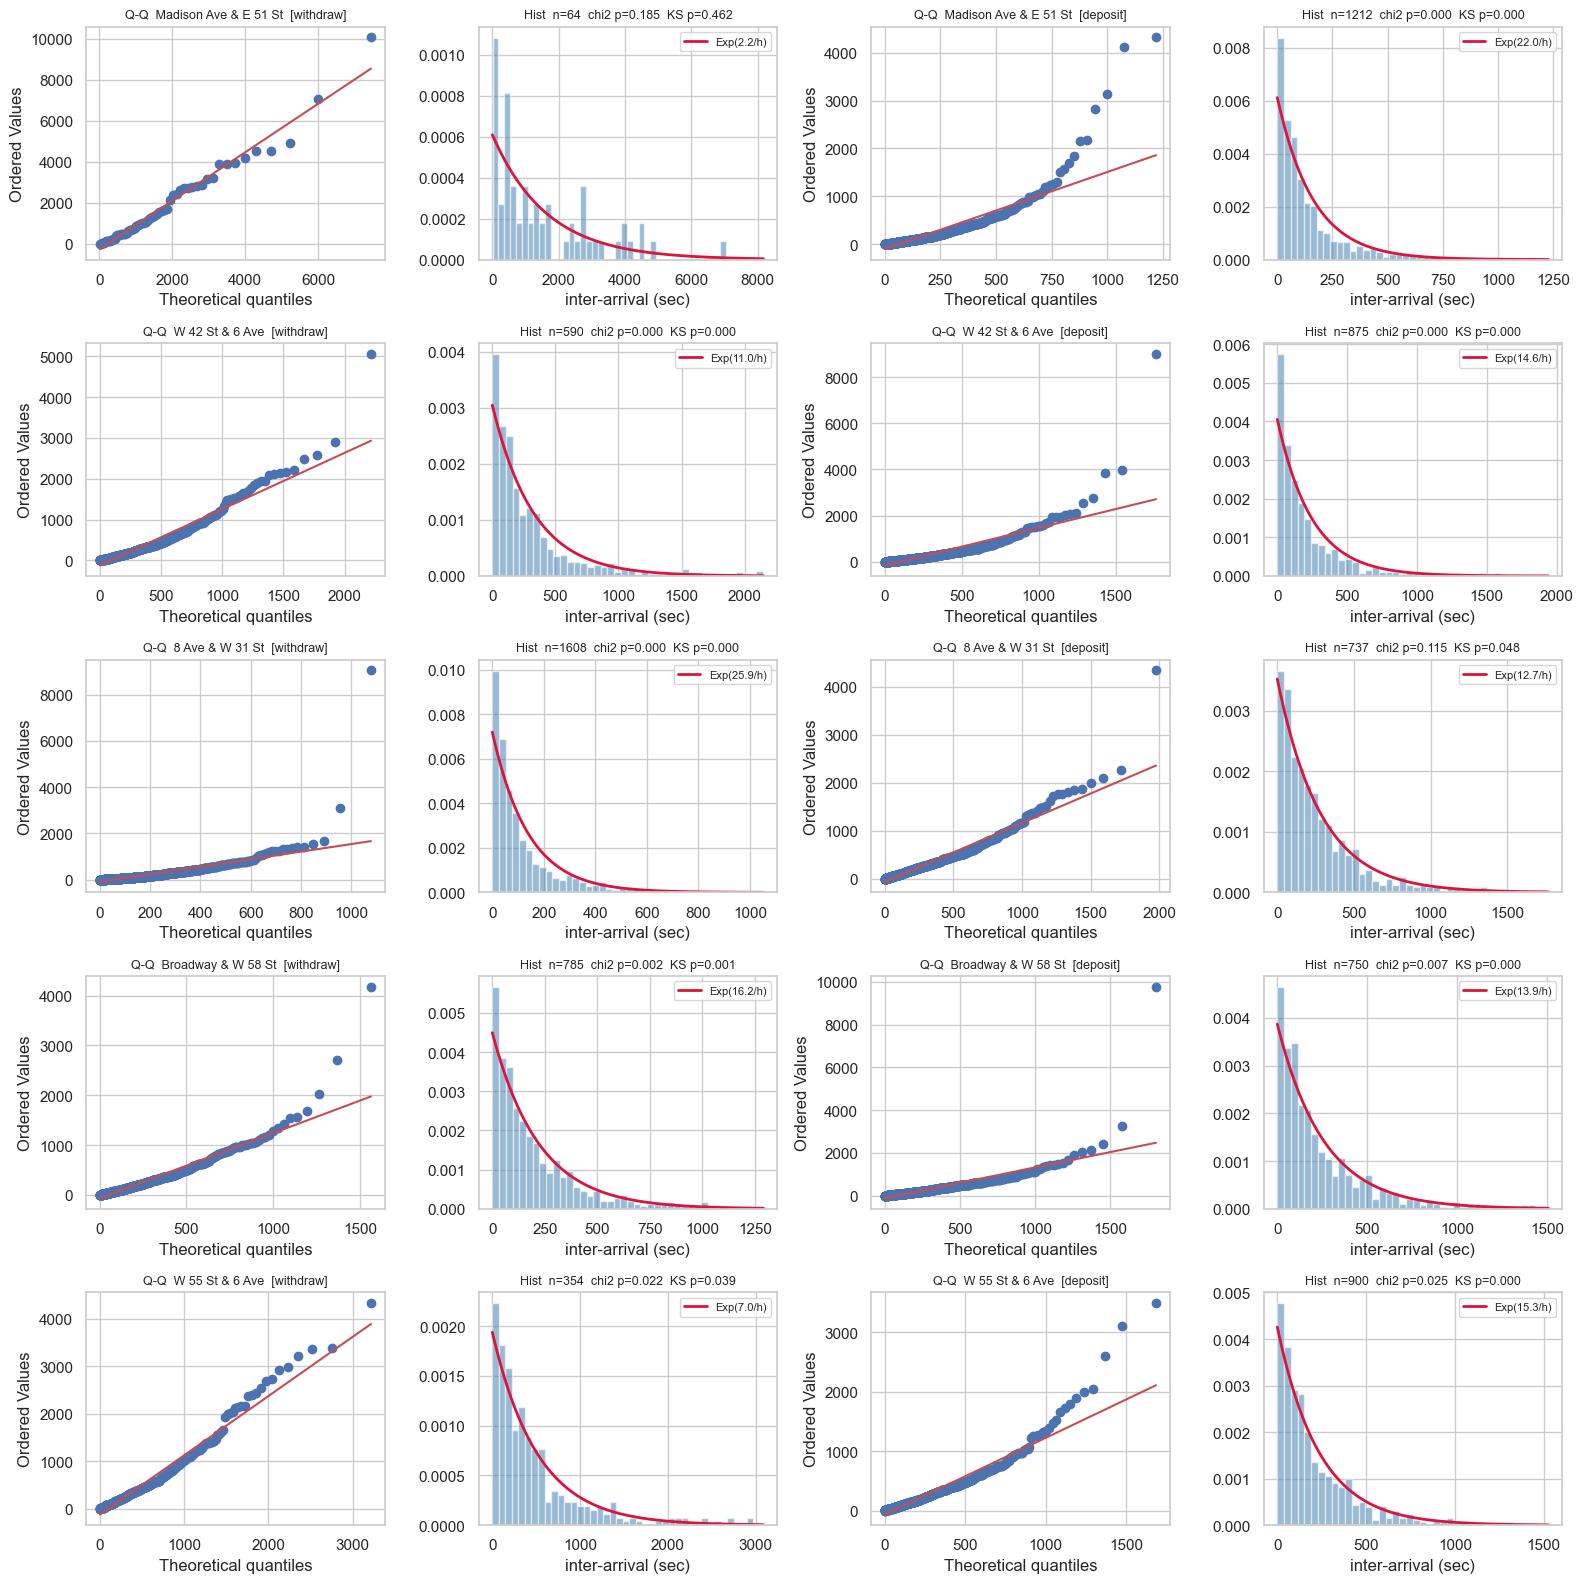

In [11]:
# For each station x event-type: collect inter-arrivals, run GOF, plot.
EVENT_TYPES = ["withdraw", "deposit"]
gof_rows = []
streams = {}  # (station_id, kind) -> inter-arrival array

n_stations = len(selected)
fig, axes = plt.subplots(n_stations, 4, figsize=(16, 3.2 * n_stations),
                          squeeze=False)

for i, srow in selected.iterrows():
    sid = srow["station_id"]
    for j, kind in enumerate(EVENT_TYPES):
        ev = dataio.station_event_times(trips, sid, kind, START_HOUR, END_HOUR)
        ia = dataio.within_day_interarrivals_seconds(ev)
        streams[(sid, kind)] = ia
        res = exp_gof(ia)
        res.update(station_id=sid, name=srow["name"], kind=kind,
                   rate_per_hour=res["rate"] * 3600 if np.isfinite(res["rate"]) else np.nan)
        gof_rows.append(res)

        # --- plots -----
        ax_qq   = axes[i, 2*j + 0]
        ax_hist = axes[i, 2*j + 1]
        if len(ia) >= 30 and np.isfinite(res["rate"]):
            mean = 1.0 / res["rate"]
            stats.probplot(ia, dist="expon", sparams=(0, mean), plot=ax_qq)
            ax_qq.set_title(f"Q-Q  {srow['name'][:25]}  [{kind}]", fontsize=9)

            # Histogram truncated to 99th pct to avoid outlier smearing.
            hi = np.quantile(ia, 0.99)
            ax_hist.hist(ia[ia <= hi], bins=40, density=True, alpha=0.55, color="steelblue")
            xs = np.linspace(0, hi, 200)
            ax_hist.plot(xs, res["rate"] * np.exp(-res["rate"] * xs),
                         color="crimson", lw=2, label=f"Exp({res['rate']*3600:.1f}/h)")
            ax_hist.set_title(
                f"Hist  n={res['n']}  chi2 p={res['chi2_p']:.3f}  KS p={res['ks_p']:.3f}",
                fontsize=9,
            )
            ax_hist.legend(fontsize=8)
            ax_hist.set_xlabel("inter-arrival (sec)")
        else:
            ax_qq.set_title(f"Q-Q  (n={res['n']} insufficient)", fontsize=9)
            ax_hist.set_title(f"Hist (n={res['n']} insufficient)", fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
# Per-station diagnostic table + pass/fail verdict.
gof = pd.DataFrame(gof_rows)
gof["pass"] = (gof["chi2_p"] > 0.05) & (gof["ks_p"] > 0.05)
display_cols = ["station_id", "name", "kind", "n", "rate_per_hour",
                "chi2_stat", "chi2_p", "ks_stat", "ks_p", "pass"]
print("Pass-fail verdict: pass iff both chi2_p > 0.05 and KS_p > 0.05.")
gof[display_cols].round(4)


Pass-fail verdict: pass iff both chi2_p > 0.05 and KS_p > 0.05.


,station_id,name,kind,n,rate_per_hour,chi2_stat,chi2_p,ks_stat,ks_p,pass
0,6659.09,Madison Ave & E 51 St,withdraw,64,2.1917,11.3125,0.1846,0.1040,0.4617,True
1,6659.09,Madison Ave & E 51 St,deposit,1212,22.0418,107.7525,0.0000,0.1269,0.0000,False
2,6517.08,W 42 St & 6 Ave,withdraw,590,10.9709,37.7966,0.0000,0.1046,0.0000,False
3,6517.08,W 42 St & 6 Ave,deposit,875,14.5949,75.8457,0.0000,0.1266,0.0000,False
4,6450.05,8 Ave & W 31 St,withdraw,1608,25.8958,160.7562,0.0000,0.1305,0.0000,False
5,6450.05,8 Ave & W 31 St,deposit,737,12.6996,12.9186,0.1147,0.0501,0.0478,False
6,6948.10,Broadway & W 58 St,withdraw,785,16.1877,24.0318,0.0023,0.0713,0.0007,False
7,6948.10,Broadway & W 58 St,deposit,750,13.9354,21.2267,0.0066,0.0763,0.0003,False
8,6809.09,W 55 St & 6 Ave,withdraw,354,6.9789,17.9209,0.0218,0.0741,0.0390,False
9,6809.09,W 55 St & 6 Ave,deposit,900,15.3238,17.5333,0.0250,0.0699,0.0003,False


In [13]:
fails = gof.loc[~gof["pass"]]
if len(fails):
    print("WARNING: the following (station, event_type) streams FAILED the exponential fit:")
    for _, r in fails.iterrows():
        print(f"  - {r['name']:<40s} [{r['kind']:<8s}]  "
              f"chi2_p={r['chi2_p']:.3f}  KS_p={r['ks_p']:.3f}  n={int(r['n'])}")
    print("\nConsider narrowing the window (e.g. 8:00-9:30 AM) to reduce non-stationarity")
    print("within the morning rush. Not retrying automatically -- this is a modelling choice,")
    print("not a data-cleaning step.")
else:
    print("All selected streams pass the exponential fit at alpha = 0.05.")


  - Madison Ave & E 51 St                    [deposit ]  chi2_p=0.000  KS_p=0.000  n=1212
  - W 42 St & 6 Ave                          [withdraw]  chi2_p=0.000  KS_p=0.000  n=590
  - W 42 St & 6 Ave                          [deposit ]  chi2_p=0.000  KS_p=0.000  n=875
  - 8 Ave & W 31 St                          [withdraw]  chi2_p=0.000  KS_p=0.000  n=1608
  - 8 Ave & W 31 St                          [deposit ]  chi2_p=0.115  KS_p=0.048  n=737
  - Broadway & W 58 St                       [withdraw]  chi2_p=0.002  KS_p=0.001  n=785
  - Broadway & W 58 St                       [deposit ]  chi2_p=0.007  KS_p=0.000  n=750
  - W 55 St & 6 Ave                          [withdraw]  chi2_p=0.022  KS_p=0.039  n=354
  - W 55 St & 6 Ave                          [deposit ]  chi2_p=0.025  KS_p=0.000  n=900

Consider narrowing the window (e.g. 8:00-9:30 AM) to reduce non-stationarity
within the morning rush. Not retrying automatically -- this is a modelling choice,
not a data-cleaning step.


## Part 3 — Base CTMC model at current capacities

For each station in the selected cluster, with the current real capacity $c_n$ from GBFS and the estimated $(\hat\lambda_n, \hat\mu_n)$ from Part 2 (events per hour):

* compute the full stationary distribution $\pi_k(n)$;
* report stockout probability $\pi_0(n)$, dockblock probability $\pi_{c_n}(n)$;
* compute the long-run failure rate $F_n(c_n) = \hat\lambda_n \pi_0(n) + \hat\mu_n \pi_{c_n}(n)$ (events/hour).

Total baseline $F_{\text{base}} = \sum_n F_n(c_n)$ is what the reallocation in notebook 02 must beat.


In [14]:
# Compute per-station pi_k, pi_0, pi_c, F_n.
base_rows = []
pi_arrays = {}
for _, s in selected.iterrows():
    lam = float(s["lam"])
    mu  = float(s["mu"])
    c   = int(s["capacity"])
    rho = mu / lam
    pi  = ctmc.stationary_distribution(rho, c)
    F_n = ctmc.failure_rate(lam, mu, c)
    pi_arrays[s["station_id"]] = pi
    base_rows.append({
        "station_id": s["station_id"],
        "name": s["name"],
        "lam": lam, "mu": mu, "c": c, "rho": rho,
        "pi_0": float(pi[0]),
        "pi_c": float(pi[-1]),
        "F_n": F_n,
        "stockout_per_hour": lam * float(pi[0]),
        "dockblock_per_hour": mu * float(pi[-1]),
        "n_events": int(s["n_events"]),
    })

base = pd.DataFrame(base_rows)
F_base = float(base["F_n"].sum())

print(f"F_base (total failure rate across the cluster) = {F_base:.3f} events/hour")
print(f"  -> over the 3-hour morning window: {F_base * 3:.1f} failed user events per weekday\n")
base.round(4)


F_base (total failure rate across the cluster) = 41.870 events/hour
  -> over the 3-hour morning window: 125.6 failed user events per weekday



,station_id,name,lam,mu,c,rho,pi_0,pi_c,F_n,stockout_per_hour,dockblock_per_hour,n_events
0,6659.09,Madison Ave & E 51 St,1.2464,17.8986,43,14.3605,0.0000,0.9304,16.6522,0.0000,16.6522,1321
1,6517.08,W 42 St & 6 Ave,8.8696,13.0000,53,1.4657,0.0000,0.3177,4.1304,0.0000,4.1304,1509
2,6450.05,8 Ave & W 31 St,23.6377,11.0145,97,0.4660,0.5340,0.0000,12.6232,12.6232,0.0000,2391
3,6948.10,Broadway & W 58 St,11.6522,11.1449,79,0.9565,0.0448,0.0013,0.5369,0.5221,0.0148,1573
4,6809.09,W 55 St & 6 Ave,5.4493,13.3768,77,2.4548,0.0000,0.5926,7.9275,0.0000,7.9275,1299


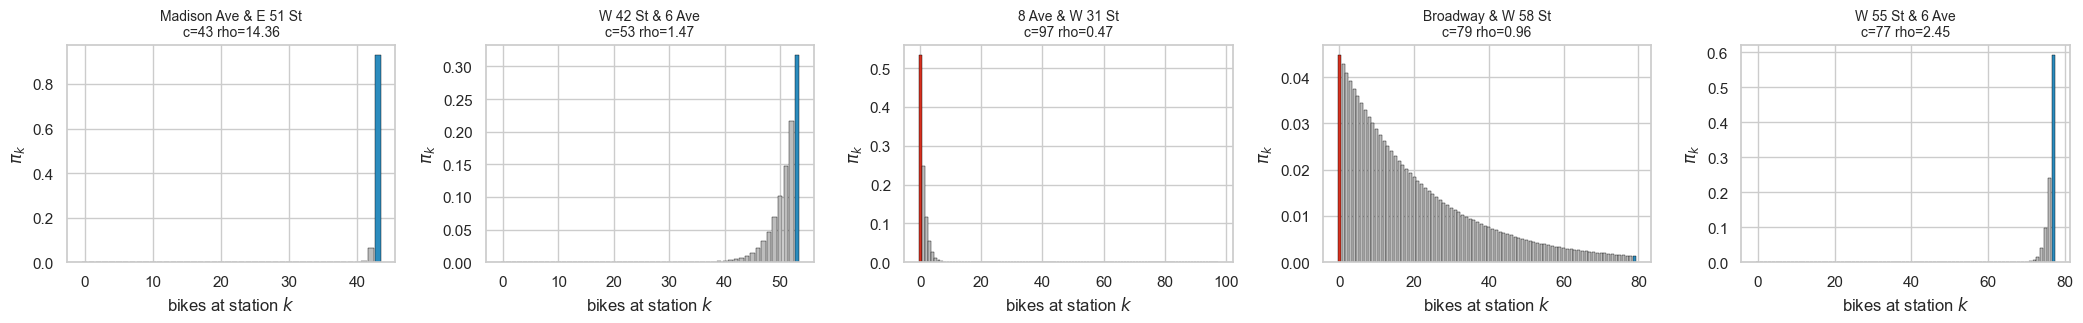

In [15]:
# Bar chart of pi_k per station (visualises where each station 'lives').
fig, axes = plt.subplots(1, len(selected), figsize=(4.2 * len(selected), 3.4), squeeze=False)
for ax, (_, s) in zip(axes[0], selected.iterrows()):
    pi = pi_arrays[s["station_id"]]
    ks = np.arange(len(pi))
    colors = ["#d7301f"] + ["#bdbdbd"] * (len(pi) - 2) + ["#2b8cbe"]
    ax.bar(ks, pi, color=colors, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{s['name'][:22]}\nc={int(s['capacity'])} rho={s['mu']/s['lam']:.2f}", fontsize=10)
    ax.set_xlabel("bikes at station $k$")
    ax.set_ylabel(r"$\pi_k$")
plt.tight_layout()
plt.show()


In [16]:
# Save the base model table for the next notebook to consume.
OUT = PROCESSED_DIR / "base_model_results.csv"
base.to_csv(OUT, index=False)
print(f"Wrote {OUT.relative_to(ROOT)} ({len(base)} rows).")
print("\nNext notebook (02_capacity_reallocation.ipynb) reads from this file and")
print(f"searches over integer allocations subject to sum(c_n) = {int(base['c'].sum())}.")


Wrote data/processed/base_model_results.csv (5 rows).

Next notebook (02_capacity_reallocation.ipynb) reads from this file and
searches over integer allocations subject to sum(c_n) = 349.


### Recap

* **Part 1** ranked candidate clusters by mean($|\log\rho|$) × volume and mapped the top 3. The selected cluster for the base model is the top-ranked candidate; override `SELECTED_CLUSTER_RANK` or `SELECTED_STATION_IDS` in the Part 2 config cell to pick a different one.
* **Part 2** produced per-(station, event-type) GOF diagnostics. Any failed stream is flagged above with a suggestion to tighten the window.
* **Part 3** saved `data/processed/base_model_results.csv` — the incumbent benchmark for the reallocation search in notebook 02.

Run `pytest tests/test_ctmc.py` to verify the closed-form helpers are still green.
